Matrix Size:    3x3    | Naive: 0.0000s | NumPy: 0.0000s | Speedup: 0.5x
Matrix Size:    6x6    | Naive: 0.0001s | NumPy: 0.0000s | Speedup: 4.2x
Matrix Size:   12x12   | Naive: 0.0004s | NumPy: 0.0000s | Speedup: 17.1x
Matrix Size:   24x24   | Naive: 0.0023s | NumPy: 0.0000s | Speedup: 66.3x
Matrix Size:   48x48   | Naive: 0.0185s | NumPy: 0.0001s | Speedup: 334.9x
Matrix Size:   96x96   | Naive: 0.1506s | NumPy: 0.0003s | Speedup: 599.1x
Matrix Size:  192x192  | Naive: 1.1511s | NumPy: 0.0006s | Speedup: 1880.9x
Matrix Size:  384x384  | Naive: 10.9702s | NumPy: 0.0037s | Speedup: 2984.3x


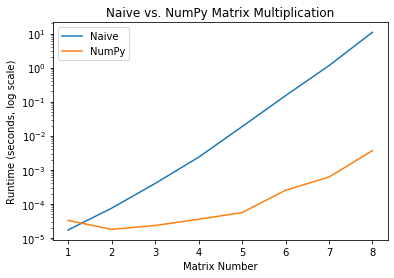

In [6]:
import numpy as np
import time
import matplotlib.pyplot as plt

#method from slides
def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    return C

#create arrays
sizes = [3 * (2**i) for i in range(8)]
naive_times = []
numpy_times = []

for n in sizes:
    #create random arrays
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)
    
    #naive time
    A_list = A.tolist()
    B_list = B.tolist()
    start = time.time()
    naive_matrix_multiplication(A_list, B_list)
    naive_times.append(time.time() - start)
    
    #numpy time
    start = time.time()
    np.dot(A, B)
    numpy_times.append(time.time() - start)
    
    ratio = naive_times[-1] / max(numpy_times[-1], 1e-9)
    print(f"Matrix Size: {n:4d}x{n:<4d} | Naive: {naive_times[-1]:.4f}s | "
          f"NumPy: {numpy_times[-1]:.4f}s | Speedup: {ratio:.1f}x")
    
matrix_numbers = list(range(1,9)) 
plt.plot(matrix_numbers, naive_times, label='Naive')
plt.plot(matrix_numbers, numpy_times, label='NumPy')
plt.xlabel('Matrix Number')
plt.ylabel('Runtime (seconds, log scale)')
plt.title('Naive vs. NumPy Matrix Multiplication')
plt.yscale('log')
plt.legend()
plt.show()